This file check that all the methods converge to the same results


In [7]:
import sys

import pandas as pd
import numpy as np
import csv
import os
from pathlib import Path


sys.path.append('/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron')
sys.path.append('/home/paule/open_mc_projects/MC-1D_DT/structured_code')

import geom_constructor
from src.geometry_classes import Geometry, Source, Material
import src.parallel as parallel
import src.export_print_csv as xp_sim


['/home/paule/anaconda3/envs/vectfit39/lib/python39.zip', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/lib-dynload', '', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages', '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron', '/home/paule/open_mc_projects/MC-1D_DT/structured_code', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit', '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron', '/home/paule/open_mc_projects/MC-1D_DT', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit']


In [8]:
xs_methods = ['serpent', 'discrete', 'vectfit']
maj_mat_methods = ['maj_mat', 'simple']
access_methods = ['fly', 'reconr']

N_NEUTRONS  = 20000  # neutrons per batch
N_BATCHES   = 50   # number of independent batches 

src = Source(
    neutron_nbr  = N_NEUTRONS,
    energy_range = [500, 150],
    energy_dist  = "mono",
    position     = [0.0, 0.0, 0.0],
    direction    = [1.0, 0.0, 0.0],
)

In [10]:

for xs_method in xs_methods:
    for maj_mat_method in maj_mat_methods:
        for access_method in access_methods:
            if xs_method == 'discrete':
                geom = None
                batch_stats = None
                
                output_dir = f"data/{xs_method}_{maj_mat_method}_{access_method}_{N_NEUTRONS}x{N_BATCHES}"
                base = Path(output_dir)

                required_files = [
                    "cross_batch_statistics_corrected.csv",
                    "memory_poll.csv",
                    "memory_summary.txt",
                ]

                error_files = [
                    "error_log.txt",
                ]

                if not base.exists():
                    # Folder doesn't exist → definitely need to run
                    to_run = True
                    base.mkdir(parents=True, exist_ok=True)

                else:
                    # Folder exists → check completeness
                    missing = [f for f in required_files if not (base / f).exists()]
                    present = [f for f in error_files if (base / f).exists()]

                    if missing:
                        print(f"Incomplete output in {output_dir}, missing: {missing}")
                        to_run = True
                    elif present:
                        print(f"Error log found in {output_dir}")
                        to_run = False
                    else:
                        to_run = True

                if not to_run:
                    print(f"Output already exists and is complete for xs_method: {xs_method}, maj_mat_method: {maj_mat_method}, access_method: {access_method}. Skipping run.")
                    continue

                elif to_run:
                                        
                    print(f"Running with xs_method: {xs_method}, maj_mat_method: {maj_mat_method}, access_method: {access_method}")
                    try:
                        geom = geom_constructor.create_geometry_U8_slab(maj_mat_method=maj_mat_method, 
                                                                        maj_xs_method=xs_method, 
                                                                        access_method=access_method, 
                                                                        mode="analysis",
                                                                    xs_maj_file_dir='/home/paule/open_mc_projects/MC-1D_DT/structured_code/src/vectfit_data')
                        
                        batch_stats = geom.run_batch_parallel(src, N_BATCHES, n_workers=20)
                    except Exception as e:
                        print(f"Error occurred while running with xs_method: {xs_method}, maj_mat_method: {maj_mat_method}, access_method: {access_method}")
                        print(f"Error message: {e}")
                        with open(base / "error_log.txt", "w") as f:
                            f.write(f"Error occurred while running with xs_method: {xs_method}, maj_mat_method: {maj_mat_method}, access_method: {access_method}\n")
                            f.write(f"Error message: {e}\n")
                        continue

                    
                    
                        
                    if batch_stats is not None and geom is not None:
                        try :
                            xp_sim.export_cross_batch_stats(
                                batch_stats=batch_stats,
                                geom=geom,
                                print_to_console=False,
                                save_csv=True,
                                output_dir=output_dir
                            )

                        except Exception as e:
                            print(f"Cross batch export failed: {e}")

                        try:
                            xp_sim.export_memory_stats(geom=geom, output_dir=output_dir)
                        except Exception as e:
                            print(f"Memory export failed: {e}")

Incomplete output in data/discrete_maj_mat_fly_20000x50, missing: ['cross_batch_statistics_corrected.csv', 'memory_poll.csv', 'memory_summary.txt']
Running with xs_method: discrete, maj_mat_method: maj_mat, access_method: fly
[Material] Processing nuclide pair: U238 (Density: 4.83e+22)
[Material] Processing nuclide pair: U238 (Density: 4.83e+22)

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
15.0

 [Memory] Tracker started (poll interval: 1 ms)
Material: cell 1       | Nuclide: U238       | Density: 4.8319e+22 atoms/cm³
Material: cell 2       | Nuclide: U238       | Density: 4.8319e+22 atoms/cm³
Majorant material composition:
  U238       : 4.8319e+22 atoms/cm³

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval


 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker started (poll interval: 1 ms)

[Simulation] Running source (Mode: analysis)

 [Memory] Tracker started (poll interval: 1 ms)
[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)


 [Memory] Tracker started (poll interval: 1 ms)
 [Memory] Tracker started (poll interval: 1 ms)


[Simulation] Running source (Mode: analysis)
[Simulation] Running source (Mode: analysis)


 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker started (poll interval: 1 ms)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

 [Memory] Tracker started (poll interval: 1 ms)

[Simulation] Running source (Mode: analysis)

 [Memory] Tracker started (poll interval: 1 ms)

[Simulation] Running source (Mode: analysis)

 [Memory] Tracker started (poll interval: 1 ms)
 [Memory] Tracker started (poll interval: 1 ms)

[Simulation] Running source (Mode: analysis)




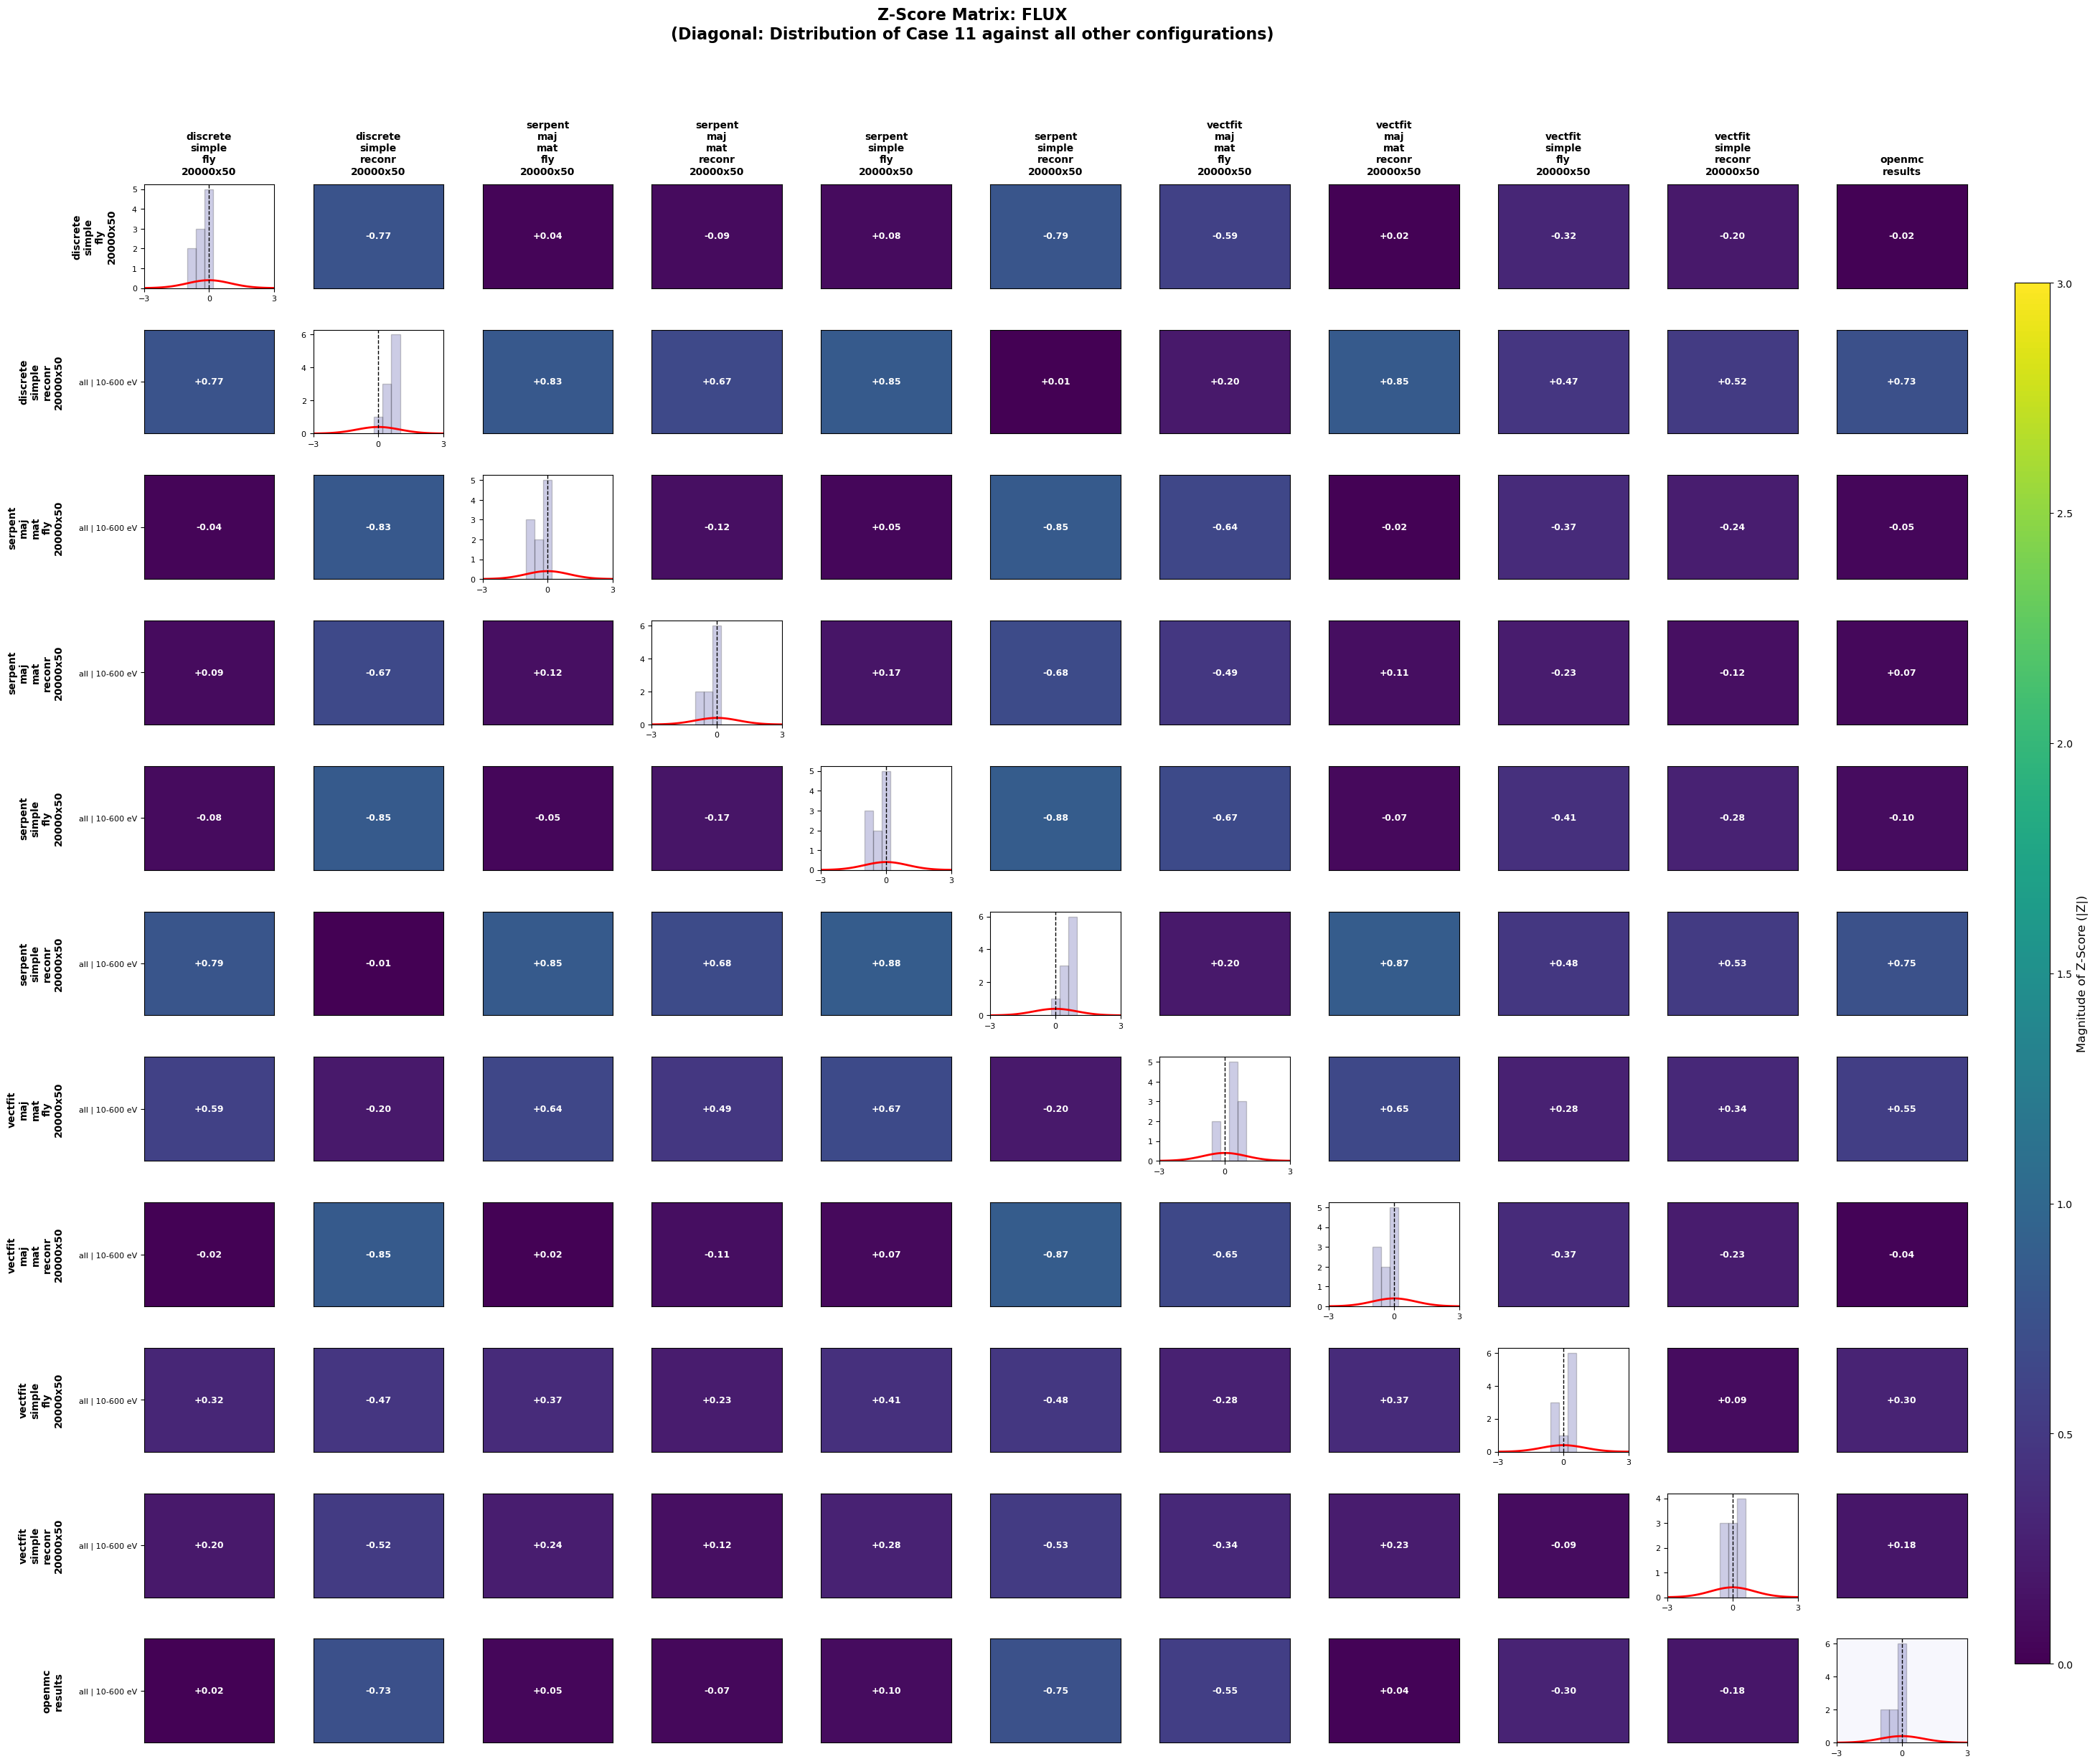

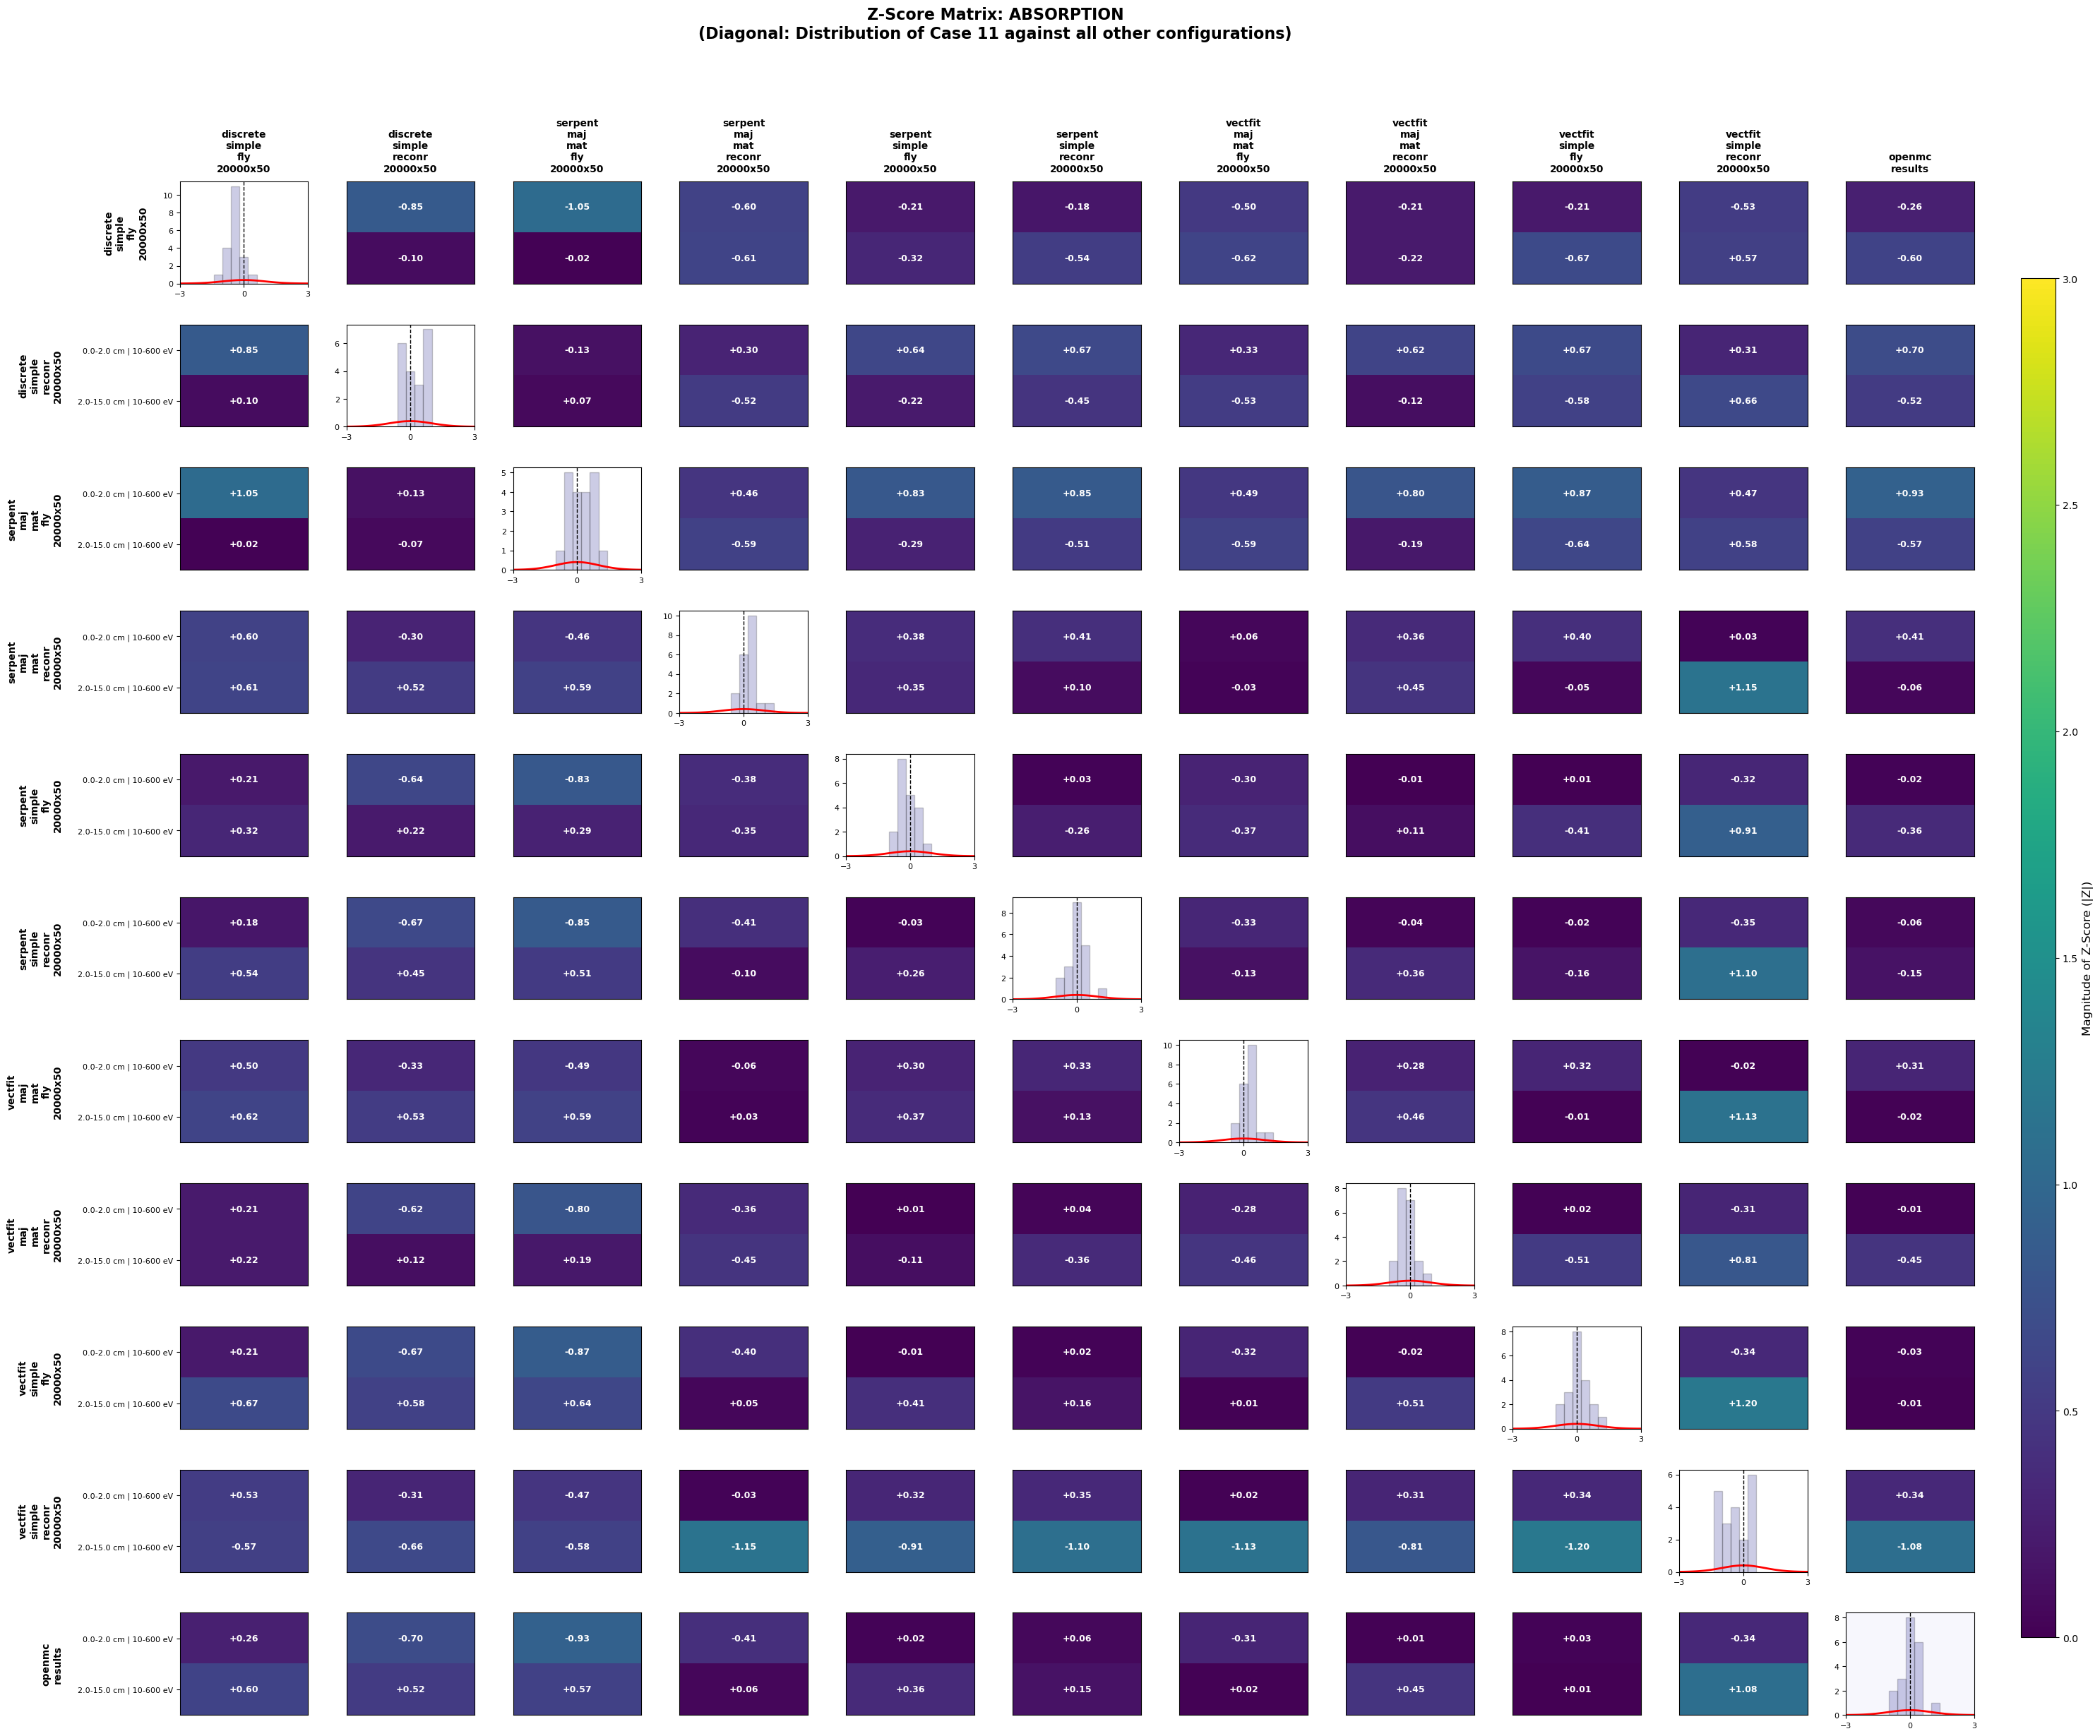

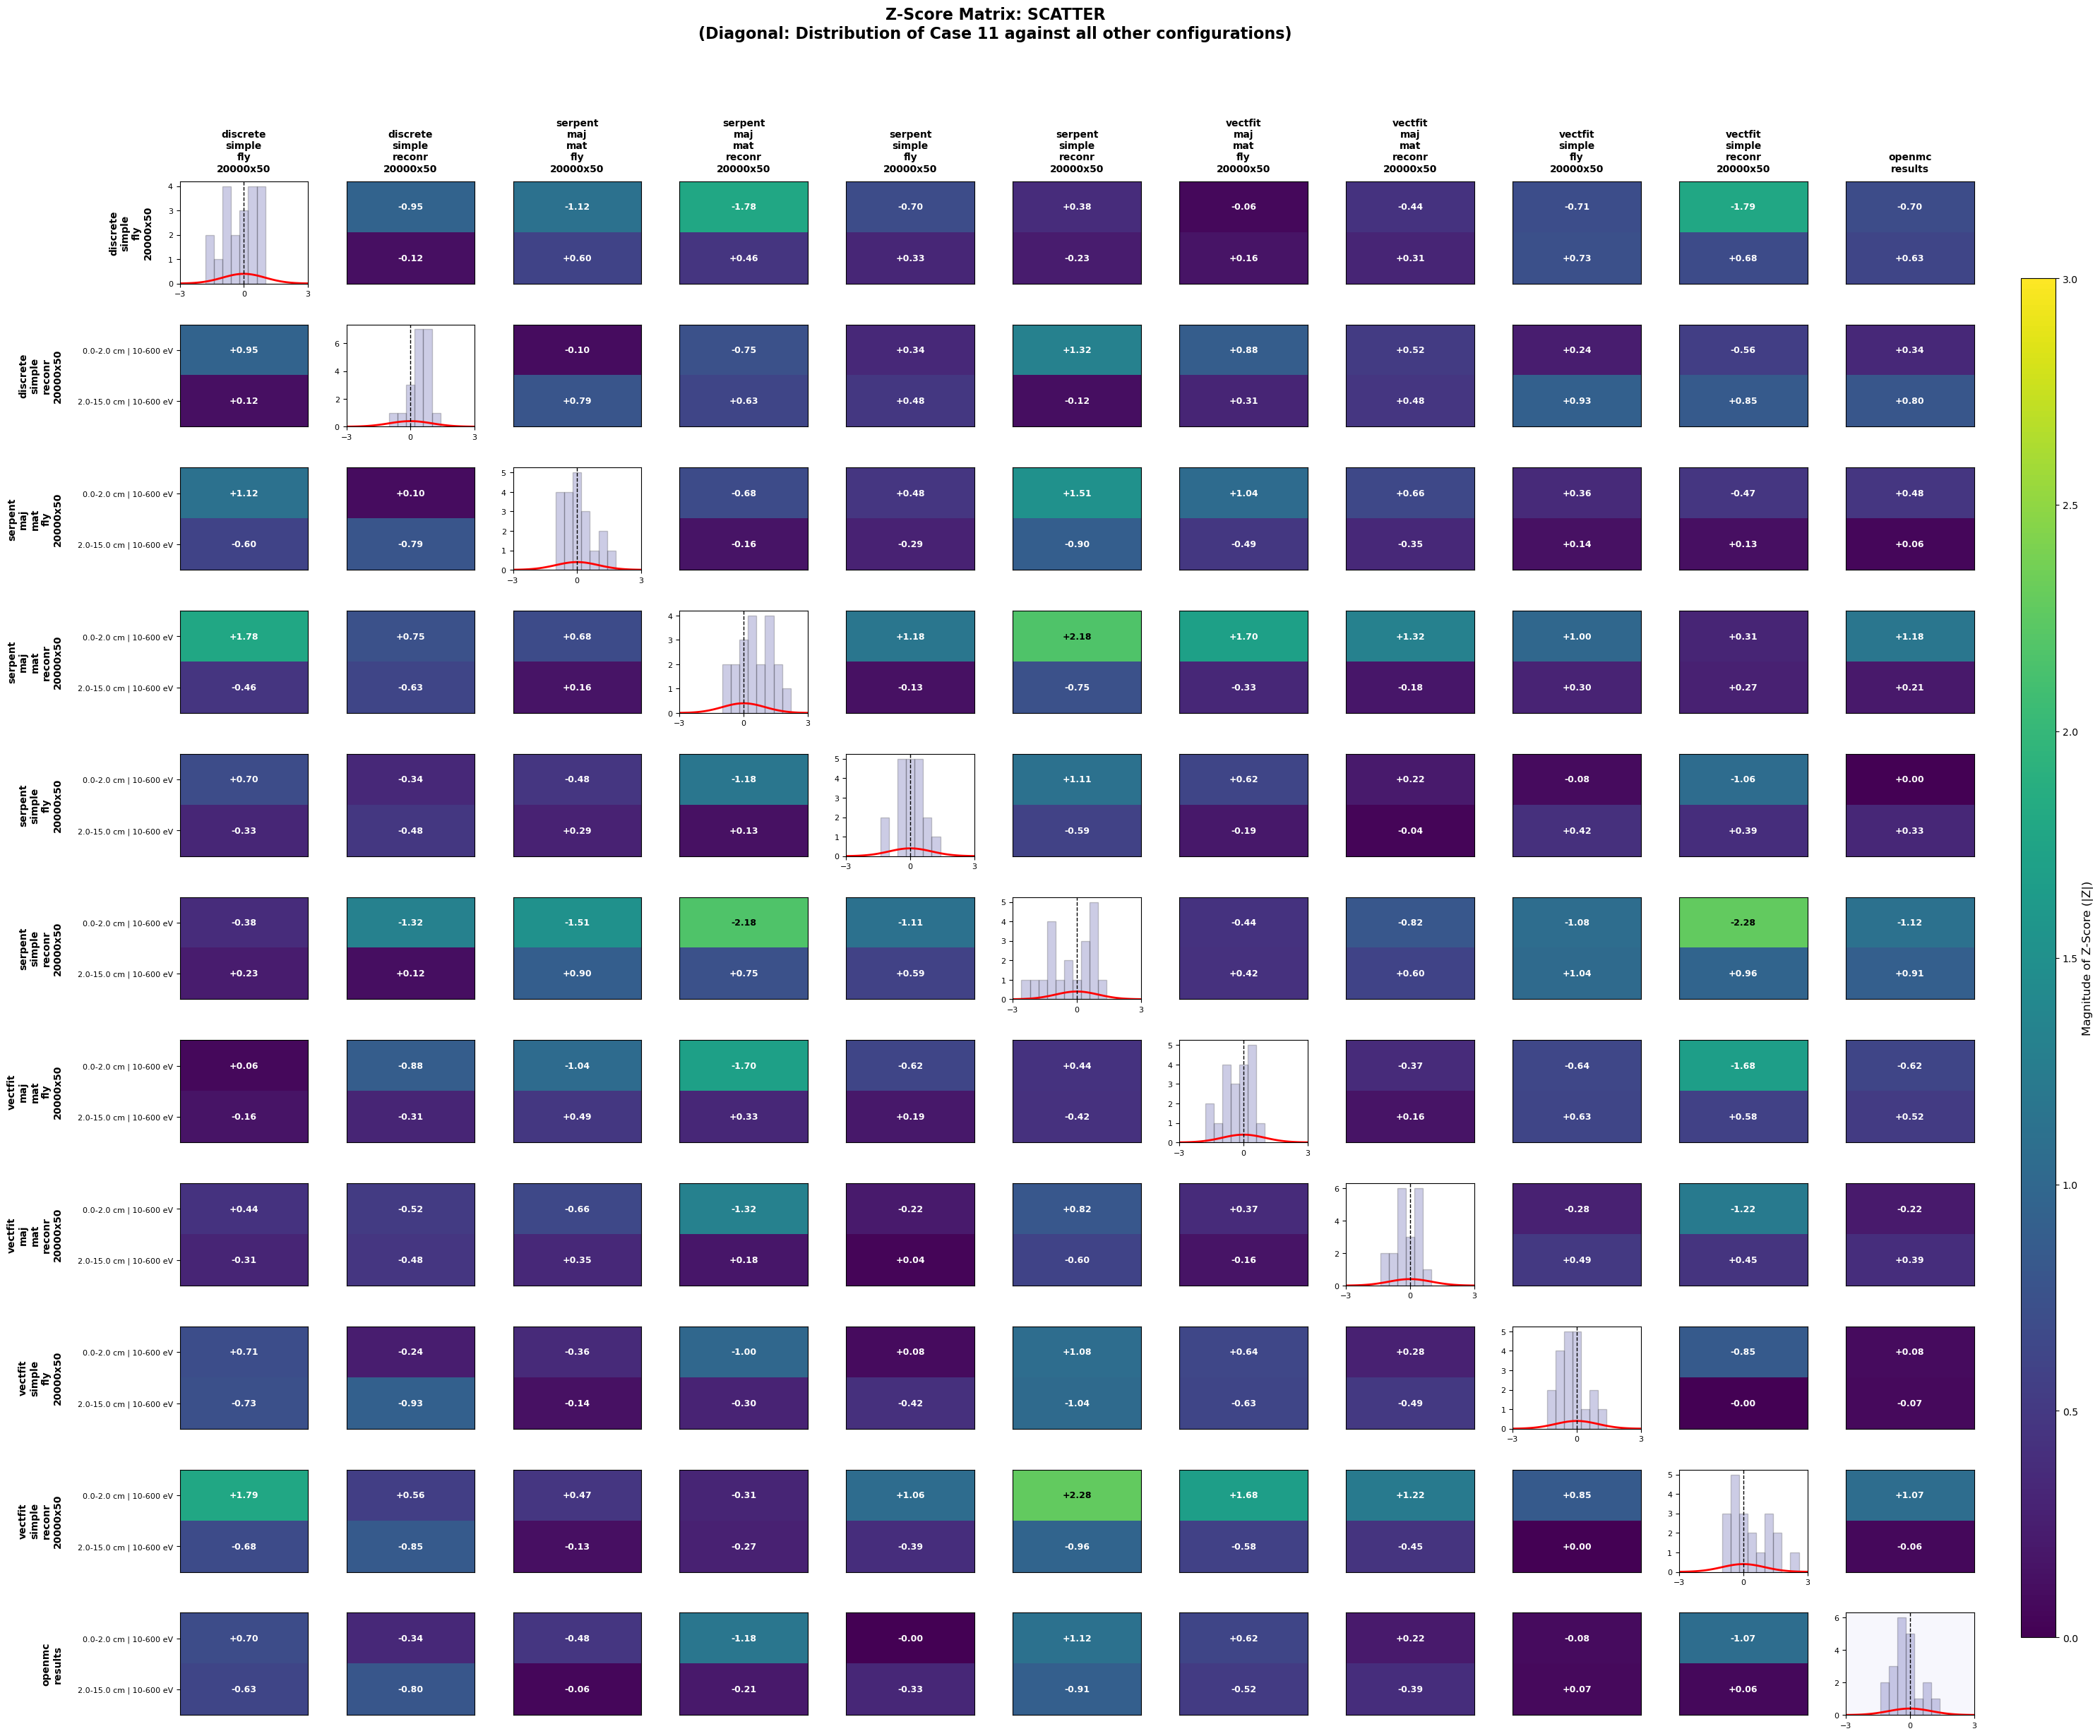

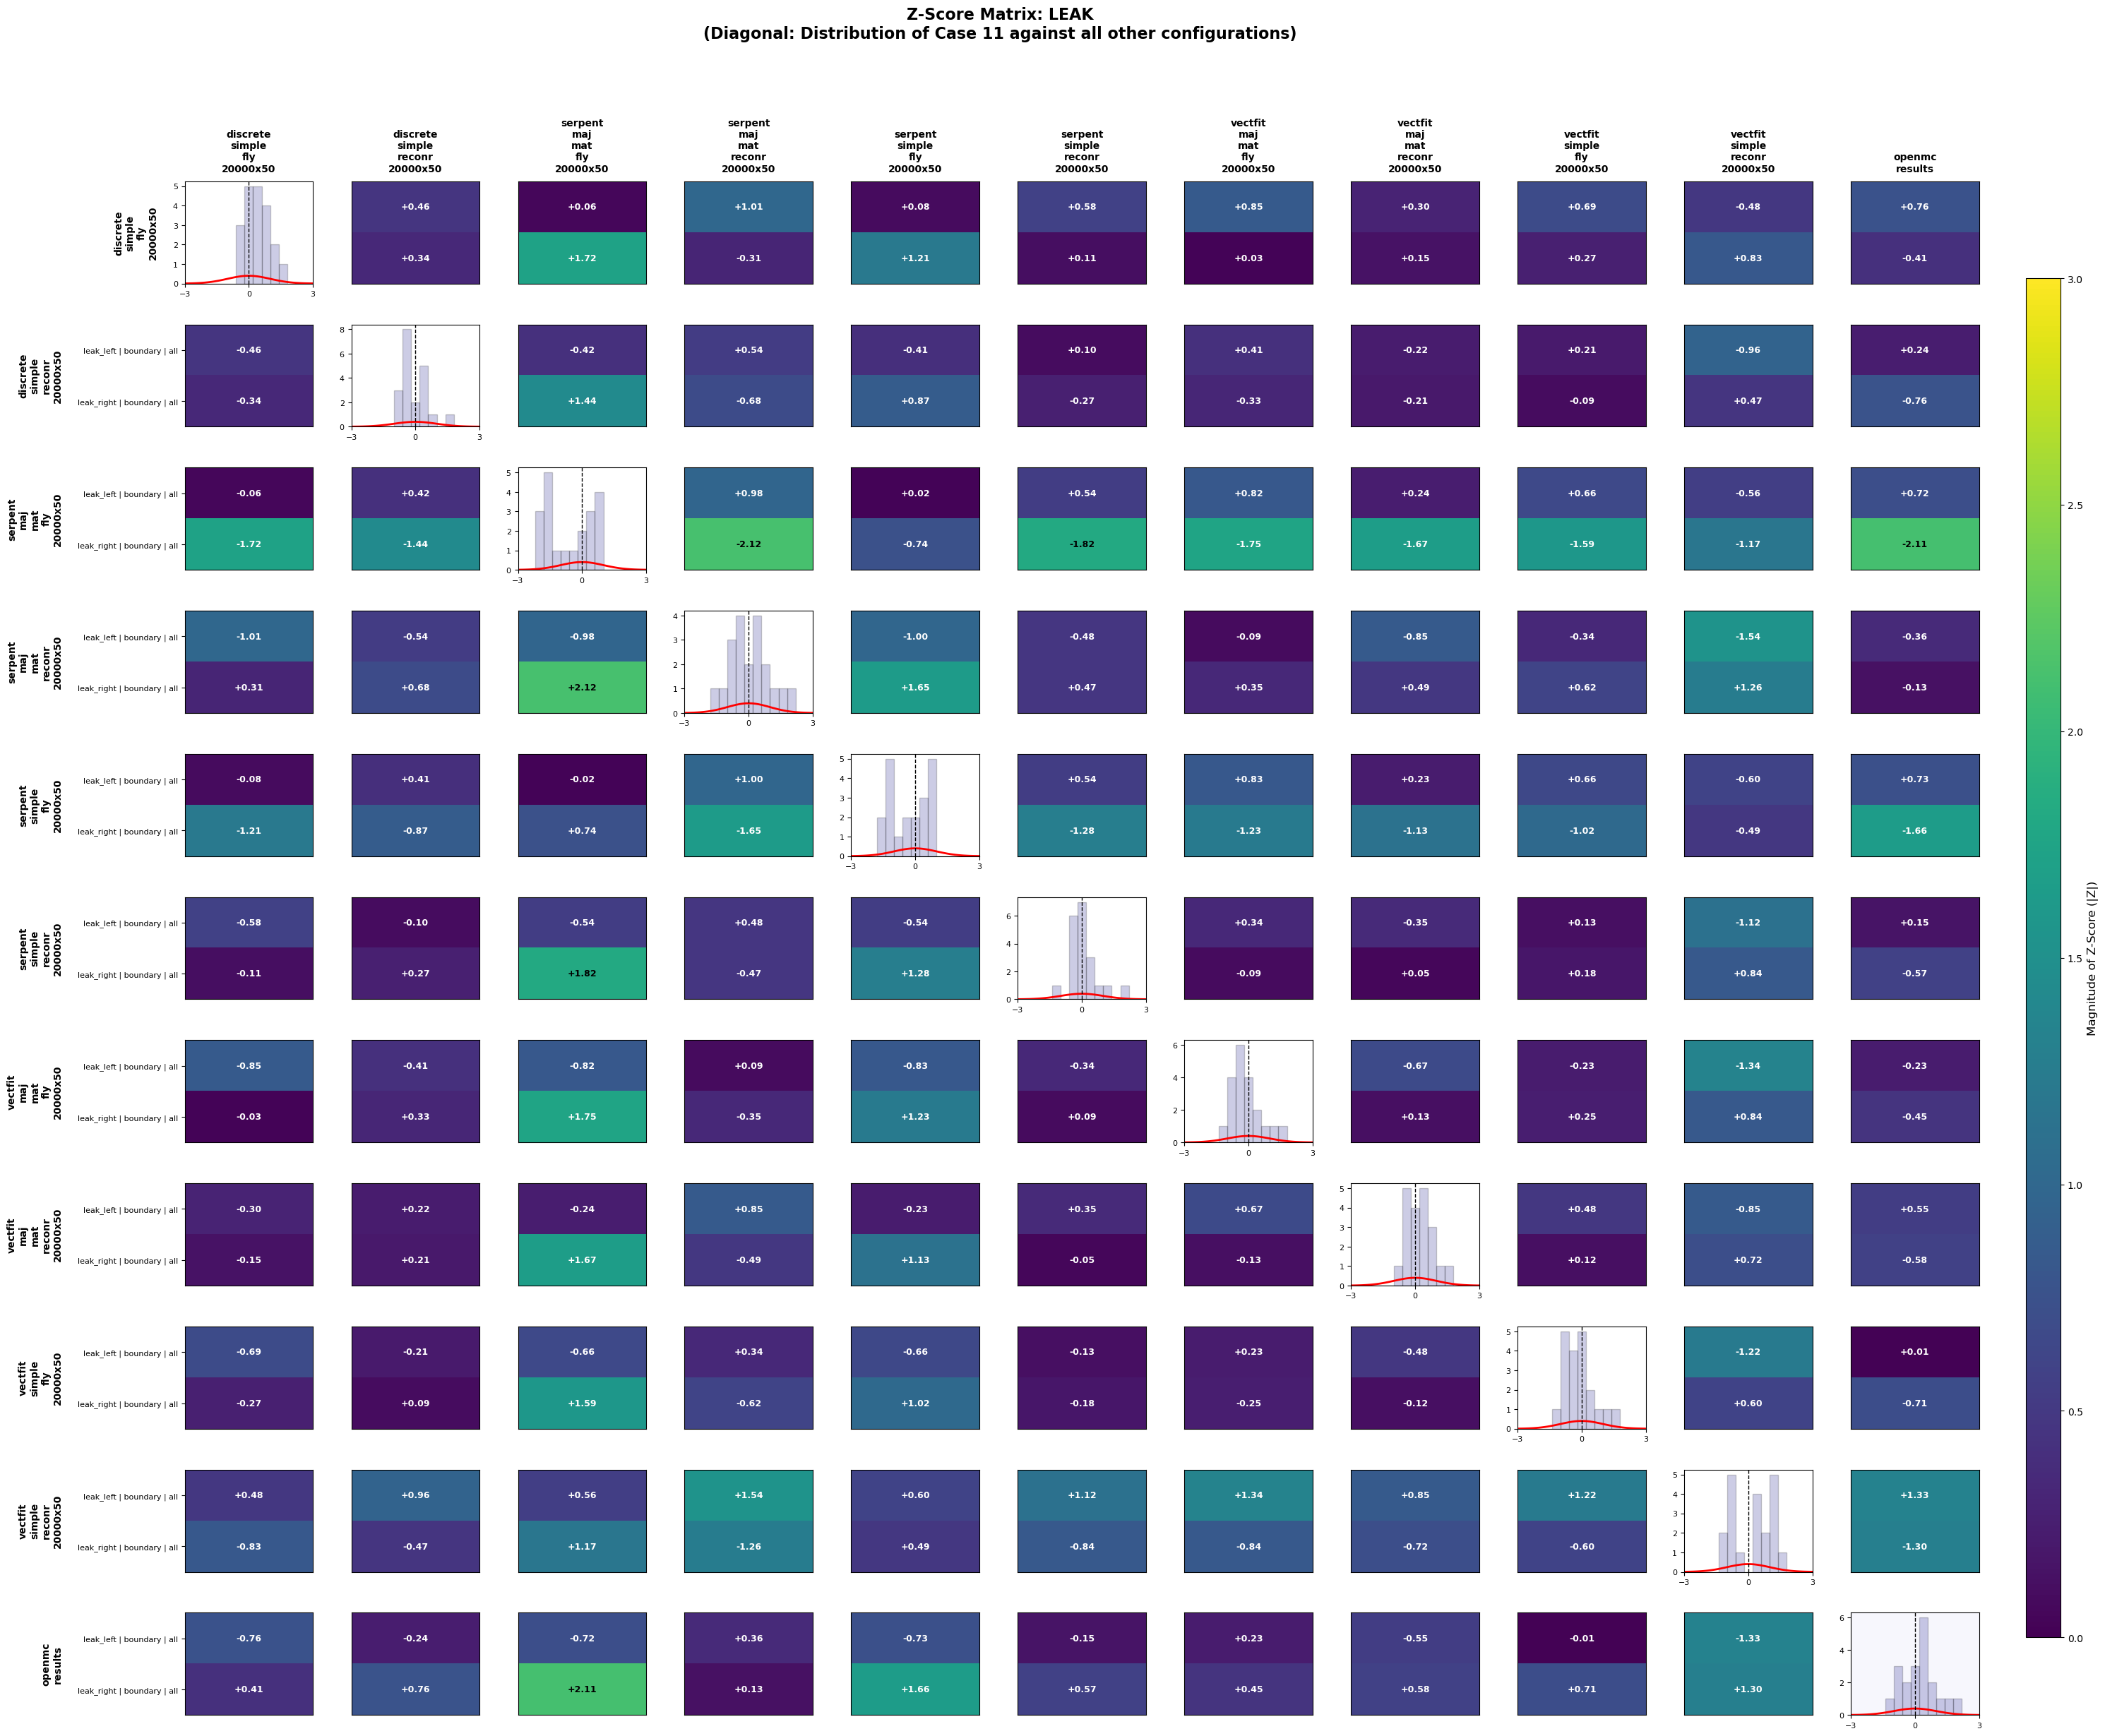

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
from scipy.stats import norm

# Use a consistent max value for the color scale (for off-diagonal heatmaps)
vmax = 3.0 

# Suppress warnings for expected math behaviors like dividing by zero
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- 1. CONFIGURATION ---
BASE_DIR = Path("data")
OPENMC_FILE = Path("/home/paule/open_mc_projects/MC-1D_DT/structured_code/validation/method_validation/openmc_results_point.csv") 

# Define the target tally families
TARGET_FAMILIES = ['flux', 'absorption', 'scatter', 'leak']

# --- 2. DATA LOADING & FILTERING ---
def load_and_filter_data(csv_path):
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path)
    if 'region' in df.columns:
        df = df[df['region'] != 'performance'].copy()
    df['tally_id'] = df['tally'] + " | " + df['region'] + " | " + df['energy_group']
    df['mean'] = df['mean'].abs()
    return df.set_index('tally_id')[['mean', 'std']]

valid_cases = {}
if BASE_DIR.exists():
    for d in BASE_DIR.iterdir():
        if d.is_dir() and not (d / "error_log.txt").exists():
            csv_path = d / "cross_batch_statistics_corrected.csv"
            df = load_and_filter_data(csv_path)
            if df is not None:
                valid_cases[d.name] = df

if OPENMC_FILE.exists():
    df = load_and_filter_data(OPENMC_FILE)
    if df is not None:
        valid_cases["openmc_results"] = df

if not valid_cases:
    raise ValueError("No valid data found.")

# --- SORTING LOGIC: ALPHABETICAL BUT OPENMC LAST ---
raw_case_names = list(valid_cases.keys())
openmc_key = "openmc_results"
if openmc_key in raw_case_names:
    raw_case_names.remove(openmc_key)
    case_names = sorted(raw_case_names)
    case_names.append(openmc_key)
else:
    case_names = sorted(raw_case_names)

n_cases = len(case_names)

# --- 3. IDENTIFY & FILTER UNIQUE TALLIES ---
all_tallies_raw = set()
for df in valid_cases.values():
    all_tallies_raw.update(df.index)

active_tallies = []
for t_id in all_tallies_raw:
    is_active = any((t_id in df.index and df.loc[t_id, 'mean'] > 0.0) for df in valid_cases.values())
    if is_active:
        active_tallies.append(t_id)

def get_family(tally_id):
    base_tally = tally_id.split(" | ")[0]
    return 'leak' if 'leak' in base_tally else base_tally

# --- 4. CALCULATE AND PLOT PER FAMILY ---
for family in TARGET_FAMILIES:
    family_tallies = sorted([t for t in active_tallies if get_family(t) == family])
    n_tallies = len(family_tallies)
    if n_tallies == 0: continue

    z_matrix = np.zeros((n_cases, n_cases, n_tallies))

    for i, name_a in enumerate(case_names):
        df_a = valid_cases[name_a]
        for j, name_b in enumerate(case_names):
            if i == j: continue 
            df_b = valid_cases[name_b]
            
            for k, tally_id in enumerate(family_tallies):
                if tally_id in df_a.index and tally_id in df_b.index:
                    mean_a, std_a = df_a.loc[tally_id, 'mean'], df_a.loc[tally_id, 'std']
                    mean_b, std_b = df_b.loc[tally_id, 'mean'], df_b.loc[tally_id, 'std']
                    variance_sum = std_a**2 + std_b**2
                    
                    if variance_sum == 0:
                        z = 0.0 if mean_a == mean_b else np.nan
                    else:
                        # SIGNED Z-SCORE: (Row - Column)
                        z = (mean_a - mean_b) / np.sqrt(variance_sum)
                    z_matrix[i, j, k] = 0.0 if not np.isfinite(z) else z

    # --- 5. VISUALIZATION ---
    fig, axes = plt.subplots(n_cases, n_cases, figsize=(max(16, 3*n_cases), max(14, 2.5*n_cases)))
    if n_cases == 2: axes = np.array(axes).reshape(2, 2)

    for i in range(n_cases):
        for j in range(n_cases):
            ax = axes[i, j]
            
            # Row/Col Labels
            if i == 0: ax.set_title(case_names[j].replace("_", "\n"), fontsize=10, fontweight='bold', pad=10)
            if j == 0: ax.set_ylabel(case_names[i].replace("_", "\n"), fontsize=10, fontweight='bold', labelpad=15)

            if i == j:
                # --- DIAGONAL: Distribution against ALL OTHER cases ---
                # Collect all signed Z-scores for Row i against every Col m (where m != i)
                all_z_samples = []
                for m in range(n_cases):
                    if m == i: continue
                    all_z_samples.extend(z_matrix[i, m, :])
                
                # Plot Histogram of pooled Z-scores
                ax.hist(all_z_samples, bins=15, range=(-3, 3), color='navy', alpha=0.2, edgecolor='black')
                
                # Overlay Standard Normal Curve N(0,1)
                x_axis = np.linspace(-3, 3, 100)
                ax.plot(x_axis, norm.pdf(x_axis, 0, 1), 'r-', lw=2, label='N(0,1)')
                
                ax.axvline(0, color='black', linestyle='--', linewidth=1.0)
                ax.set_xlim(-3, 3)
                ax.set_xticks([-3, 0, 3])
                ax.tick_params(axis='both', which='both', labelsize=8)
                
                # Highlight if OpenMC is the row
                if case_names[i] == "openmc_results":
                    ax.patch.set_facecolor('lavender')
                    ax.patch.set_alpha(0.3)
                continue
                
            # OFF-DIAGONAL: Heatmap of Z-score
            z_vals = z_matrix[i, j, :].reshape(-1, 1)
            # Use absolute value for background color to show intensity of discrepancy
            im = ax.imshow(np.abs(z_vals), aspect='auto', cmap='viridis', vmin=0, vmax=vmax)
            
            # Add signed Z-value text
            for k, z in enumerate(z_vals.flatten()):
                text_color = "black" if np.abs(z) > (vmax * 0.6) else "white"
                text_str = "0" if z == 0 else f"{z:+.2f}"
                ax.text(0, k, text_str, ha='center', va='center', color=text_color, fontsize=9, fontweight='bold')

            ax.set_xticks([])
            if j == 0:
                clean_labels = [t.replace(f"{family} | ", "") for t in family_tallies]
                ax.set_yticks(range(n_tallies))
                ax.set_yticklabels(clean_labels, fontsize=8)
            else:
                ax.set_yticks([])

    # Colorbar & Layout
    cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7]) 
    fig.colorbar(im, cax=cbar_ax).set_label(f'Magnitude of Z-Score (|Z|)', fontsize=12)
    plt.suptitle(f"Z-Score Matrix: {family.upper()}\n(Diagonal: Distribution of Case {i+1} against all other configurations)", fontsize=16, fontweight='bold', y=0.99)
    plt.subplots_adjust(left=0.15, top=0.9, right=0.92, wspace=0.3, hspace=0.4)
    plt.show()

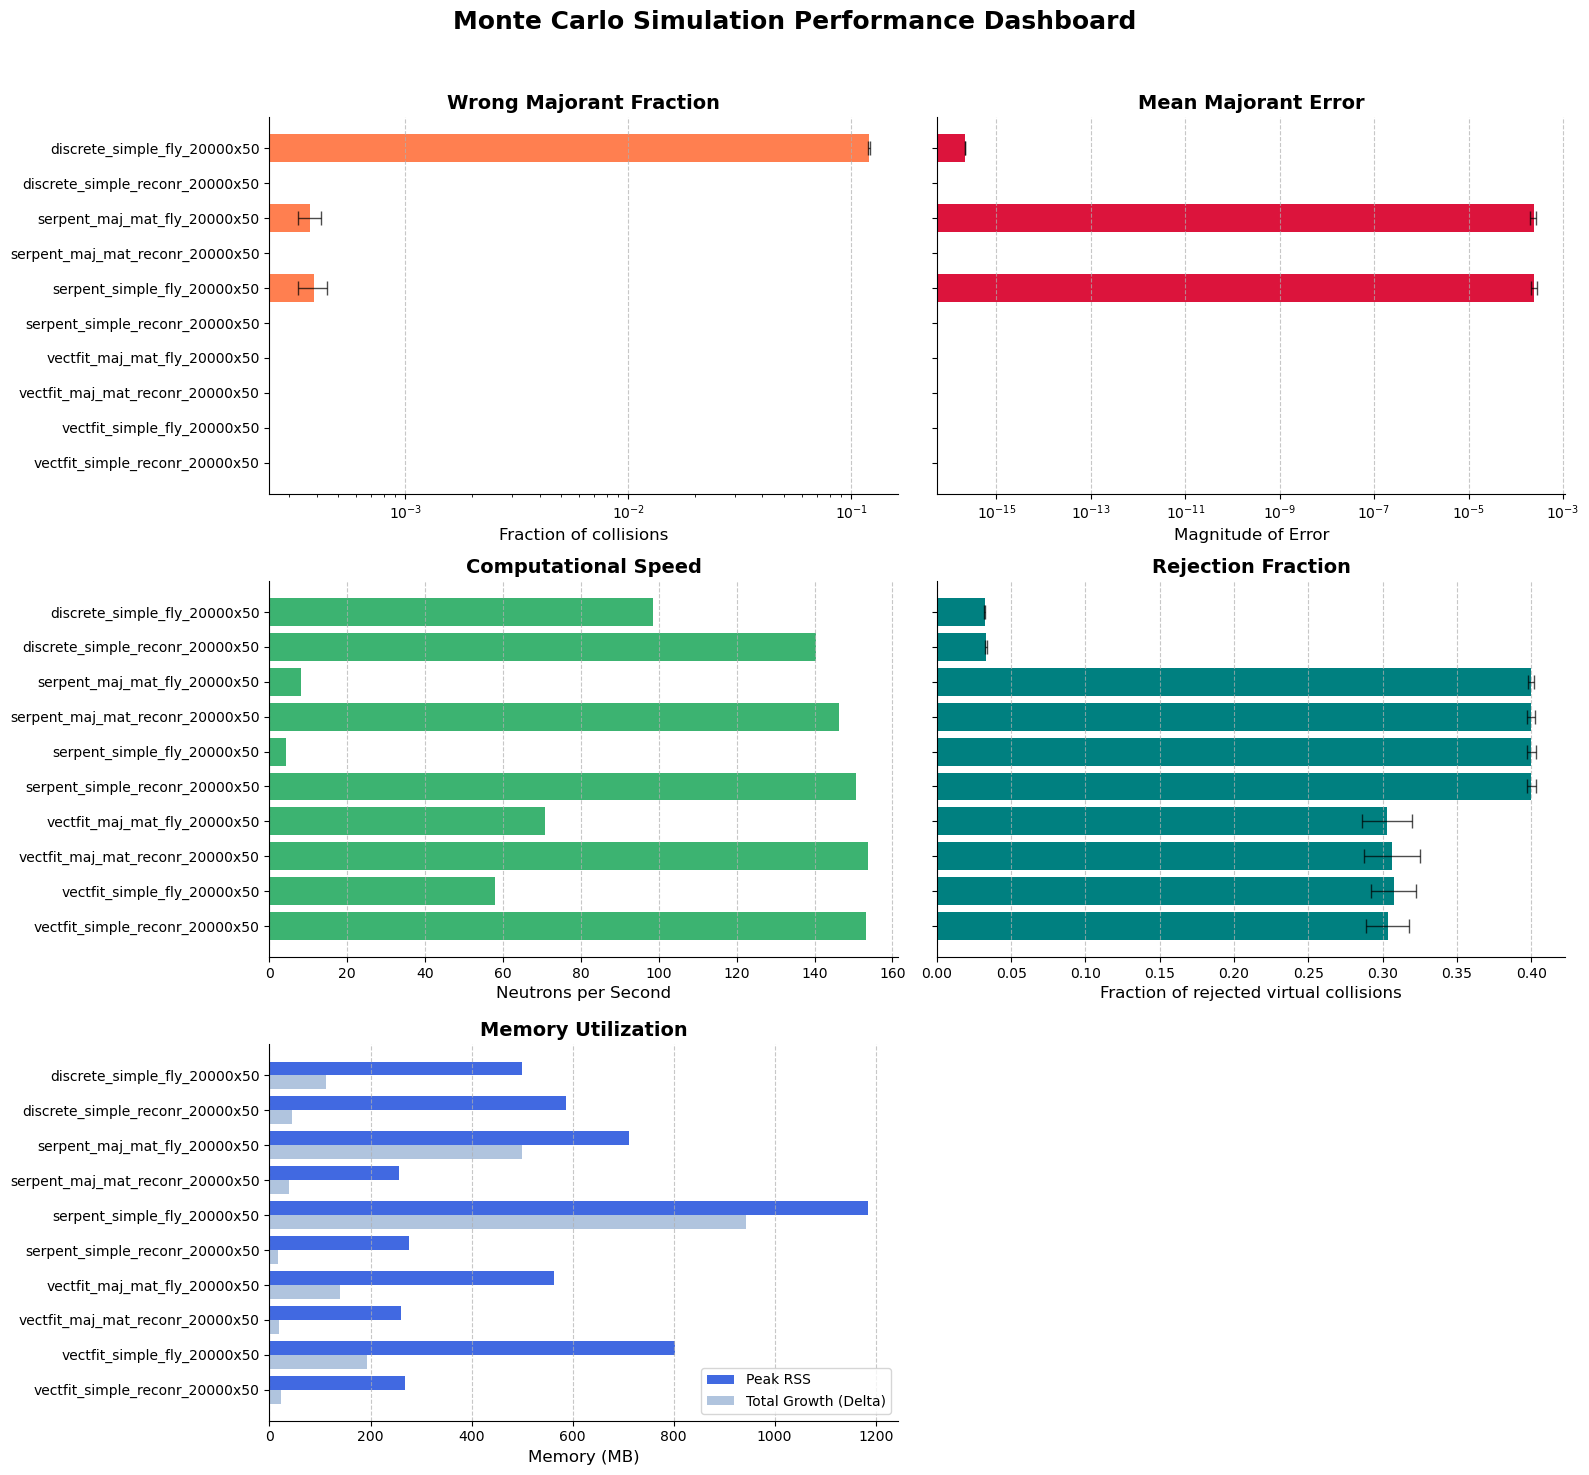

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# --- 1. CONFIGURATION ---
BASE_DIR = Path("data")

# --- 2. DATA EXTRACTION ---
case_names = []
metrics = {
    'wrong_maj_frac': [],
    'wrong_maj_frac_std': [], # NEW: Standard Deviation
    'wrong_maj_err': [],
    'wrong_maj_err_std': [],  # NEW: Standard Deviation
    'nps': [],
    'rej_frac': [],
    'rej_frac_std': [],       # NEW: Standard Deviation
    'peak_mem': [],
    'delta_mem': []
}

if BASE_DIR.exists():
    for d in BASE_DIR.iterdir():
        # Only process valid run directories (ignore OpenMC and failed runs)
        if d.is_dir() and not (d / "error_log.txt").exists() and d.name != "openmc_results":
            
            # --- Read Performance CSV ---
            csv_file = d / "cross_batch_statistics_corrected.csv"
            if csv_file.exists():
                df = pd.read_csv(csv_file)
                # Filter specifically for the performance tallies
                perf_df = df[df['region'] == 'performance'].set_index('tally')
                
                # Extract means safely
                metrics['wrong_maj_frac'].append(perf_df.loc['wrong_majorant_fraction', 'mean'] if 'wrong_majorant_fraction' in perf_df.index else 0)
                metrics['wrong_maj_err'].append(perf_df.loc['wrong_majorant_mean_error', 'mean'] if 'wrong_majorant_mean_error' in perf_df.index else 0)
                metrics['nps'].append(perf_df.loc['neutrons_per_second', 'mean'] if 'neutrons_per_second' in perf_df.index else 0)
                metrics['rej_frac'].append(perf_df.loc['rejection_fraction', 'mean'] if 'rejection_fraction' in perf_df.index else 0)
                
                # Extract standard deviations safely
                metrics['wrong_maj_frac_std'].append(perf_df.loc['wrong_majorant_fraction', 'std'] if 'wrong_majorant_fraction' in perf_df.index else 0)
                metrics['wrong_maj_err_std'].append(perf_df.loc['wrong_majorant_mean_error', 'std'] if 'wrong_majorant_mean_error' in perf_df.index else 0)
                metrics['rej_frac_std'].append(perf_df.loc['rejection_fraction', 'std'] if 'rejection_fraction' in perf_df.index else 0)
            else:
                continue # Skip if CSV doesn't exist
            
            # --- Read Memory Summary TXT ---
            mem_file = d / "memory_summary.txt"
            peak, delta = 0.0, 0.0
            if mem_file.exists():
                with open(mem_file, 'r') as f:
                    content = f.read()
                    
                    # Regex to extract numeric values from the specific summary lines
                    m_peak = re.search(r'Peak RSS \(continuous\)\s*:\s*([\d\.e\+\-]+)', content)
                    m_growth = re.search(r'Total growth\s*:\s*\+?([\d\.e\+\-]+)', content)
                    
                    if m_peak: peak = float(m_peak.group(1))
                    if m_growth: delta = float(m_growth.group(1))
                    
            metrics['peak_mem'].append(peak)
            metrics['delta_mem'].append(delta)
            
            # Add case name cleanly
            case_names.append(d.name)

# Make sure we have data to plot
if not case_names:
    raise ValueError("No valid performance data found in the directories.")

# Sort data alphabetically by case name
sort_idx = np.argsort(case_names)
case_names = [case_names[i] for i in sort_idx]
for key in metrics:
    metrics[key] = [metrics[key][i] for i in sort_idx]

# --- 3. VISUALIZATION DASHBOARD ---
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle("Monte Carlo Simulation Performance Dashboard", fontsize=18, fontweight='bold', y=0.98)

# Helper function to format horizontal bar charts
def format_ax(ax, title, xlabel):
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # INVERT Y-AXIS to force alphabetical reading from top to bottom
    ax.invert_yaxis() 

y_pos = np.arange(len(case_names))

# Plot 1: Wrong Majorant Fraction (Added Error Bars)
ax = axes[0, 0]
bars = ax.barh(y_pos, metrics['wrong_maj_frac'], xerr=metrics['wrong_maj_frac_std'], capsize=5, error_kw={'linewidth': 1, 'alpha': 0.7}, color='coral')
ax.set_yticks(y_pos)
ax.set_yticklabels(case_names, fontsize=10)
# set x_axis to log scale to better visualize small fractions
ax.set_xscale('log')
format_ax(ax, "Wrong Majorant Fraction", "Fraction of collisions")

# Plot 2: Wrong Majorant Mean Error (Added Error Bars)
ax = axes[0, 1]
ax.barh(y_pos, metrics['wrong_maj_err'], xerr=metrics['wrong_maj_err_std'], capsize=5, error_kw={'linewidth': 1, 'alpha': 0.7}, color='crimson')
ax.set_yticks(y_pos)
ax.set_yticklabels([]) # Hide labels to save space since they match the left plot
ax.set_xscale('log')
format_ax(ax, "Mean Majorant Error", "Magnitude of Error")

# Plot 3: Efficiency - Neutrons Per Second
ax = axes[1, 0]
ax.barh(y_pos, metrics['nps'], color='mediumseagreen')
ax.set_yticks(y_pos)
ax.set_yticklabels(case_names, fontsize=10)
format_ax(ax, "Computational Speed", "Neutrons per Second")

# Plot 4: Efficiency - Rejection Fraction (Added Error Bars)
ax = axes[1, 1]
ax.barh(y_pos, metrics['rej_frac'], xerr=metrics['rej_frac_std'], capsize=5, error_kw={'linewidth': 1, 'alpha': 0.7}, color='teal')
ax.set_yticks(y_pos)
ax.set_yticklabels([]) 
format_ax(ax, "Rejection Fraction", "Fraction of rejected virtual collisions")

# Plot 5: Memory (Grouped Bar Chart for Peak and Delta)
ax = axes[2, 0]
height = 0.4
# Shift the bars slightly so they sit next to each other
ax.barh(y_pos - height/2, metrics['peak_mem'], height=height, label='Peak RSS', color='royalblue')
ax.barh(y_pos + height/2, metrics['delta_mem'], height=height, label='Total Growth (Delta)', color='lightsteelblue')

ax.set_yticks(y_pos)
ax.set_yticklabels(case_names, fontsize=10)
format_ax(ax, "Memory Utilization", "Memory (MB)")
ax.legend(loc='lower right')

# Hide the 6th unused subplot
axes[2, 1].axis('off')

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [13]:
import pandas as pd
import numpy as np
from pathlib import Path

# --- 1. CONFIGURATION ---
BASE_DIR = Path("data")
OPENMC_FILE = Path("/home/paule/open_mc_projects/MC-1D_DT/structured_code/validation/method_validation/openmc_results_point.csv") 

# --- 2. DATA LOADING & FILTERING ---
def load_and_filter_data(csv_path):
    """Loads the CSV, filters performance data, applies absolute values, and indexes."""
    if not csv_path.exists():
        return None
    
    df = pd.read_csv(csv_path)
    
    # Filter out performance/memory data if it exists
    if 'region' in df.columns:
        df = df[df['region'] != 'performance'].copy()
    
    # Create a unique identifier for each tally bin
    df['tally_id'] = df['tally'] + " | " + df['region'] + " | " + df['energy_group']
    
    # .abs() guarantees backward currents/leaks are treated as positive probabilities
    df['mean'] = df['mean'].abs()
    
    return df.set_index('tally_id')[['mean', 'std']]

# Gather all valid cases
valid_cases = {}

if BASE_DIR.exists():
    for d in BASE_DIR.iterdir():
        if d.is_dir() and not (d / "error_log.txt").exists():
            csv_path = d / "cross_batch_statistics_corrected.csv"
            df = load_and_filter_data(csv_path)
            if df is not None:
                valid_cases[d.name] = df

if OPENMC_FILE.exists():
    df = load_and_filter_data(OPENMC_FILE)
    if df is not None:
        valid_cases["openmc_results"] = df

if not valid_cases:
    raise ValueError("No valid data found.")

# --- 3. CALCULATE NEUTRON BALANCE ---
results = []

for case_name, df in valid_cases.items():
    # Sum all absorption bins (across all regions and energy groups)
    total_abs = df[df.index.str.startswith('absorption')]['mean'].sum()
    
    # Sum all leak bins (leak_left + leak_right)
    total_leak = df[df.index.str.contains('leak')]['mean'].sum()
    
    # Calculate balance
    total = total_abs + total_leak
    diff = abs(1.0 - total)
    
    results.append({
        'Case Name': case_name,
        'Absorption': total_abs,
        'Leakage': total_leak,
        'Total (Abs + Leak)': total,
        'Difference from 1.0': diff
    })

# --- 4. DISPLAY RESULTS ---
# Convert to a DataFrame for clean, aligned printing
balance_df = pd.DataFrame(results)

# Sort alphabetically, but put openmc_results at the bottom
openmc_mask = balance_df['Case Name'] == 'openmc_results'
sorted_df = pd.concat([
    balance_df[~openmc_mask].sort_values('Case Name'),
    balance_df[openmc_mask]
]).reset_index(drop=True)

print("=" * 105)
print(f"{'Neutron Balance Check (Target = 1.0)':^105}")
print("=" * 105)

# Print with specific formatting for readability
# FIX: Use the .format method so pandas has a callable function for each column
format_dict = {
    'Absorption': '{:.5f}'.format, 
    'Leakage': '{:.5f}'.format, 
    'Total (Abs + Leak)': '{:.5f}'.format, 
    'Difference from 1.0': '{:.5e}'.format
}

# Apply formatting and print as a string
print(sorted_df.to_string(index=False, formatters=format_dict, justify='left'))
print("-" * 105)

                                  Neutron Balance Check (Target = 1.0)                                   
Case Name                       Absorption Leakage Total (Abs + Leak) Difference from 1.0
   discrete_simple_fly_20000x50 0.47688    0.52312 1.00000            0.00000e+00        
discrete_simple_reconr_20000x50 0.47732    0.52268 1.00000            2.22045e-16        
   serpent_maj_mat_fly_20000x50 0.47732    0.52268 1.00000            2.22045e-16        
serpent_maj_mat_reconr_20000x50 0.47758    0.52242 1.00000            0.00000e+00        
    serpent_simple_fly_20000x50 0.47719    0.52281 1.00000            0.00000e+00        
 serpent_simple_reconr_20000x50 0.47734    0.52266 1.00000            2.22045e-16        
   vectfit_maj_mat_fly_20000x50 0.47758    0.52242 1.00000            2.22045e-16        
vectfit_maj_mat_reconr_20000x50 0.47712    0.52288 1.00000            0.00000e+00        
    vectfit_simple_fly_20000x50 0.47746    0.52254 1.00000            2.22045e-16   

CASE NAME                           | ABSORPTION   | SCATTERING   | TOTAL RX    
-------------------------------------------------------------------------------------
discrete_simple_fly_20000x50        | 0.47688      | 7.18312      | 7.66000
discrete_simple_reconr_20000x50     | 0.47732      | 7.18821      | 7.66553
serpent_maj_mat_fly_20000x50        | 0.47732      | 7.18042      | 7.65774
serpent_maj_mat_reconr_20000x50     | 0.47758      | 7.18489      | 7.66247
serpent_simple_fly_20000x50         | 0.47719      | 7.18176      | 7.65895
serpent_simple_reconr_20000x50      | 0.47734      | 7.18433      | 7.66167
vectfit_maj_mat_fly_20000x50        | 0.47758      | 7.18156      | 7.65914
vectfit_maj_mat_reconr_20000x50     | 0.47712      | 7.18138      | 7.65850
vectfit_simple_fly_20000x50         | 0.47746      | 7.17750      | 7.65496
vectfit_simple_reconr_20000x50      | 0.47666      | 7.18064      | 7.65731
openmc_results                      | 0.47748      | 7.17800      | 7.655

/tmp/ipykernel_681642/1058469344.py:77: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', n_sims)


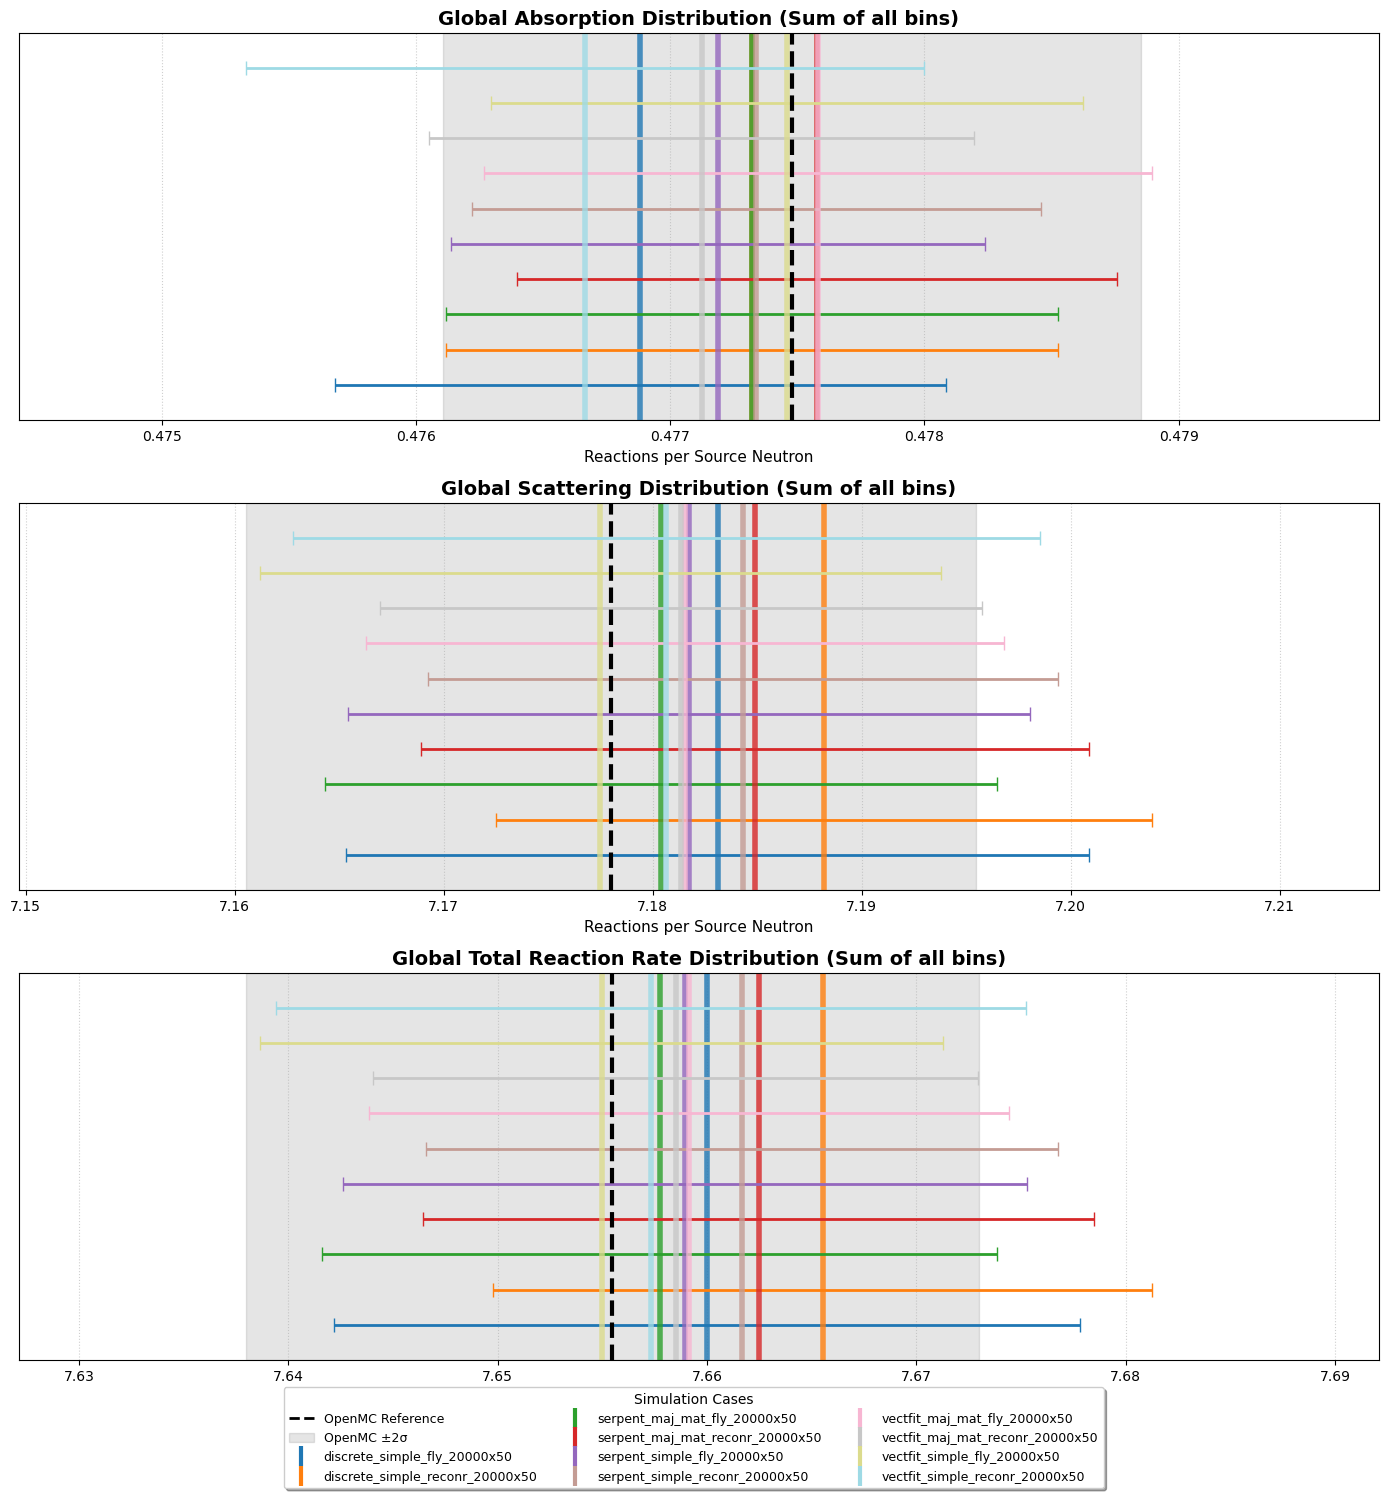

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
import warnings

# --- 1. CONFIGURATION ---
BASE_DIR = Path("data")
OPENMC_FILE = Path("/home/paule/open_mc_projects/MC-1D_DT/structured_code/validation/method_validation/openmc_results_point.csv") 

warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- 2. DATA LOADING & INDEXING ---
def load_and_filter_data(csv_path):
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path)
    if 'region' in df.columns:
        df = df[df['region'] != 'performance'].copy()
    df['tally_id'] = df['tally'] + " | " + df['region'] + " | " + df['energy_group']
    df['mean'] = df['mean'].abs()
    return df.set_index('tally_id')[['mean', 'std']]

valid_cases = {}
if BASE_DIR.exists():
    for d in BASE_DIR.iterdir():
        if d.is_dir() and not (d / "error_log.txt").exists():
            csv_path = d / "cross_batch_statistics_corrected.csv"
            df = load_and_filter_data(csv_path)
            if df is not None:
                valid_cases[d.name] = df

if OPENMC_FILE.exists():
    df = load_and_filter_data(OPENMC_FILE)
    if df is not None:
        valid_cases["openmc_results"] = df

case_names = sorted([c for c in valid_cases.keys() if c != "openmc_results"])
sim_cases = case_names.copy()
if "openmc_results" in valid_cases:
    case_names.append("openmc_results")

# --- 3. CALCULATE GLOBAL TOTALS ---
metrics = ['Absorption', 'Scattering', 'Total Reaction Rate']
global_data = {m: pd.DataFrame(index=valid_cases.keys(), columns=['Mean', 'Std']) for m in metrics}

for case_name, df in valid_cases.items():
    # Absorption
    abs_mask = df.index.str.startswith('absorption')
    m_abs = df[abs_mask]['mean'].sum()
    s_abs = np.sqrt((df[abs_mask]['std']**2).sum())
    global_data['Absorption'].loc[case_name] = [m_abs, s_abs]
    
    # Scattering
    scat_mask = df.index.str.startswith('scatter')
    m_scat = df[scat_mask]['mean'].sum()
    s_scat = np.sqrt((df[scat_mask]['std']**2).sum())
    global_data['Scattering'].loc[case_name] = [m_scat, s_scat]
    
    # Total Reaction Rate
    m_rx = m_abs + m_scat
    s_rx = np.sqrt(s_abs**2 + s_scat**2)
    global_data['Total Reaction Rate'].loc[case_name] = [m_rx, s_rx]

# --- 4. PRINT SUMMARY TABLE ---
print(f"{'CASE NAME':<35} | {'ABSORPTION':<12} | {'SCATTERING':<12} | {'TOTAL RX':<12}")
print("-" * 85)
for case in case_names:
    a = global_data['Absorption'].loc[case, 'Mean']
    s = global_data['Scattering'].loc[case, 'Mean']
    r = global_data['Total Reaction Rate'].loc[case, 'Mean']
    print(f"{case:<35} | {a:.5f}      | {s:.5f}      | {r:.5f}")

# --- 5. VISUALIZATION ---
n_sims = len(sim_cases)
colors = plt.cm.get_cmap('tab20', n_sims)
color_map = {case: colors(i) for i, case in enumerate(sim_cases)}

# We create one figure with 3 subplots (one for each global metric)
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for ax, metric in zip(axes, metrics):
    res_df = global_data[metric]
    vals_for_lims = []
    
    # Plot simulation cases with staggered error bars (1-sigma)
    for i, case in enumerate(sim_cases):
        mean = res_df.loc[case, 'Mean']
        std = 2*res_df.loc[case, 'Std']
        
        ax.axvline(mean, color=color_map[case], linewidth=4, alpha=0.8)
        y_pos = (i + 1) / (n_sims + 1)
        ax.errorbar(mean, y_pos, xerr=std, color=color_map[case], fmt='none', capsize=5, elinewidth=2)
        vals_for_lims.extend([mean - std, mean + std])

    # Plot OpenMC Reference
    if "openmc_results" in res_df.index:
        ref_mean = res_df.loc["openmc_results", 'Mean']
        ref_std = 2 * res_df.loc["openmc_results", 'Std']
        ax.axvline(ref_mean, color='black', linestyle='--', linewidth=3)
        ax.axvspan(ref_mean - ref_std, ref_mean + ref_std, color='black', alpha=0.1)
        vals_for_lims.extend([ref_mean - ref_std, ref_mean + ref_std])

    # Styling
    if vals_for_lims:
        vmin, vmax_v = min(vals_for_lims), max(vals_for_lims)
        pad = (vmax_v - vmin) * 0.25 if vmax_v != vmin else 0.05 * vmin
        ax.set_xlim(vmin - pad, vmax_v + pad)

    ax.set_title(f"Global {metric} Distribution (Sum of all bins)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Reactions per Source Neutron", fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.grid(True, axis='x', linestyle=':', alpha=0.6)

# Shared Legend
legend_handles = [
    mlines.Line2D([], [], color='black', linestyle='--', linewidth=2, label='OpenMC Reference'),
    plt.Rectangle((0, 0), 1, 1, color='black', alpha=0.1, label='OpenMC ±2σ')
]
for case in sim_cases:
    legend_handles.append(mlines.Line2D([], [], color=color_map[case], marker='|', 
                                        markersize=15, linestyle='None', markeredgewidth=3, label=case))

fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.02), 
           ncol=3, fontsize=9, frameon=True, shadow=True, title="Simulation Cases")

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()